In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Load data (from Day 1)
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler

housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target

# ============================================
# PART 1: SIMPLE LINEAR REGRESSION (1 feature)
# ============================================

# Prepare data
X_simple = df[['MedInc']]  # 1 column
y = df['MedHouseVal']

# Split
X_train_simple, X_test_simple, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

print("Simple Linear Regression:")
print(f"X_train shape: {X_train_simple.shape}")
print(f"X_test shape: {X_test_simple.shape}")
print()

# Simple linear regression
class LinearRegressionGD:
    def __init__(self, learning_rate=0.01, n_iterations=100):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations

    def fit(self, X, y):
        n_samples = len(X)

# Initialize w and b to 0
        w = 0
        b = 0

# Make the iterations
        for iteration in range(self.n_iterations):


# Make predictions using current w and b
            y_pred = w * X + b

# Calculate the error
            error = y_pred - y

# Calculate the cost
            cost = 1/2 * n_samples * np.sum(error ** 2)

# Calculate the Derivatives
            dw = (1/n_samples) * sum(error * X)
            db = (1/n_samples) * sum(error)

# Update w and b
            w = w - self.learning_rate * dw
            b = b - self.learning_rate * db

# Print progress after every 10 iteration
            if iteration % 10 == 0:
                print(f"iterations : {iteration:3d}, cost : {cost:.4f}")

        self.w = w
        self.b = b
        return self

    def predict(self, X):
        return np.dot(X, self.w) + self.b

# Train the model
model_simple = LinearRegressionGD(learning_rate=0.01, n_iterations=100)
model_simple.fit(X_train_simple.values, y_train.values.reshape(-1,1))

# Predict
y_pred_simple = model_simple.predict(X_test_simple.values)

# Calculate error
simple_mse = np.mean((y_pred_simple.flatten() - y_test) ** 2)
print(f"Simple Model MSE: {simple_mse:.4f}")



Simple Linear Regression:
X_train shape: (16512, 1)
X_test shape: (4128, 1)

iterations :   0, cost : 767463768.0538
iterations :  10, cost : 107021537.8141
iterations :  20, cost : 98290318.1876
iterations :  30, cost : 98072976.9471
iterations :  40, cost : 97970584.5729
iterations :  50, cost : 97873330.9455
iterations :  60, cost : 97779649.2529
iterations :  70, cost : 97689390.9678
iterations :  80, cost : 97602430.7622
iterations :  90, cost : 97518648.1200
Simple Model MSE: 0.7282


In [3]:
# ============================================
# PART 2: POLYNOMIAL REGRESSION (3 degrees)
# ============================================
from sklearn.preprocessing import StandardScaler

# Create polynomial features
X_poly = np.column_stack([
    df['MedInc'],      # degree 1
    df['MedInc'] ** 2, # degree 2
    df['MedInc'] ** 3  # degree 3
])

# Scale features
scaler = StandardScaler()
X_poly_scaled = scaler.fit_transform(X_poly)

# Split polynomial features
X_train_poly, X_test_poly, y_train, y_test = train_test_split(
    X_poly_scaled, y, test_size=0.2, random_state=42
)


# Polynomial Regression
class PolynomialRegressionGD:
    def __init__(self, learning_rate=0.01, n_iterations=500):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.cost_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros((n_features, 1))
        self.bias = 0

        for iteration in range(self.n_iterations):

# Make predictions using current w and b
            y_pred_poly = np.dot(X, self.weights) + self.bias

# Calculate the cost
            cost_poly = (1/n_samples) * np.sum(y_pred_poly - y)** 2
            self.cost_history.append(cost_poly)

# Calculate the Derivatives
            dw_poly = (2/n_samples) * np.dot(X.T,(y_pred_poly - y))
            db_poly = (2/n_samples) * np.sum(y_pred_poly - y)

# Update the w and b
            self.weights -= self.learning_rate * dw_poly
            self.bias -= self.learning_rate * db_poly

# make the iterations
            if iteration % 50 == 0:
                print(f"iterations : {iteration:3d}, cost : {cost_poly:.4f}")
        return self

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

# Train
model_poly = PolynomialRegressionGD(learning_rate=0.01, n_iterations=500)
model_poly.fit(X_train_poly, y_train.values.reshape(-1,1))

# Predict
y_pred_poly = model_poly.predict(X_test_poly)

# Calculate error
poly_mse = np.mean((y_pred_poly.flatten() - y_test) ** 2)
print(f"Polynomial Model MSE: {poly_mse:.4f}")


iterations :   0, cost : 70885.4234
iterations :  50, cost : 9359.4335
iterations : 100, cost : 1239.4317
iterations : 150, cost : 164.0320
iterations : 200, cost : 21.6548
iterations : 250, cost : 2.8422
iterations : 300, cost : 0.3681
iterations : 350, cost : 0.0462
iterations : 400, cost : 0.0054
iterations : 450, cost : 0.0005
Polynomial Model MSE: 0.7008


In [4]:
# After training
print(f"First cost: {model_poly.cost_history[0]:.4f}")
print(f"Last cost: {model_poly.cost_history[-1]:.4f}")
print(f"Improvement: {model_poly.cost_history[0] / model_poly.cost_history[-1]:.0f}x better!")

First cost: 70885.4234
Last cost: 0.0000
Improvement: 2688412125x better!


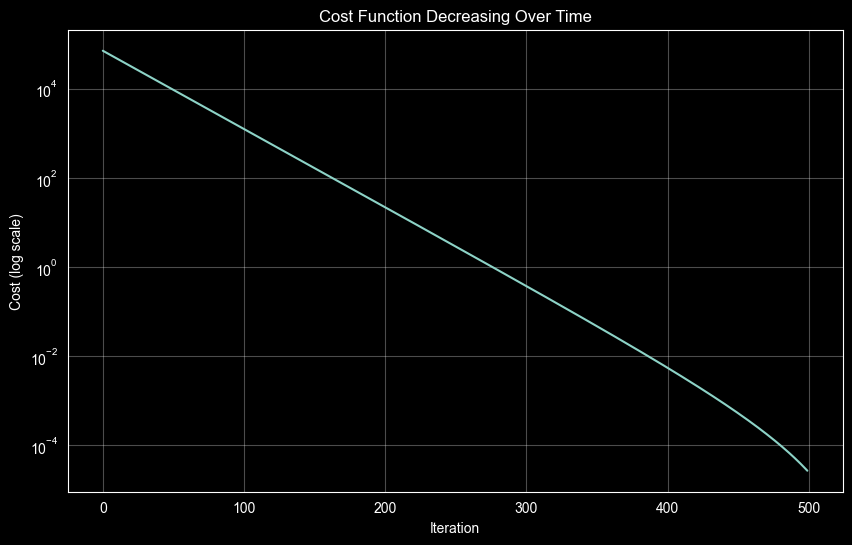

In [5]:
# PLOT YOUR COST HISTORY
plt.figure(figsize=(10, 6))
plt.plot(model_poly.cost_history)
plt.yscale('log')  # Log scale shows progress better
plt.xlabel("Iteration")
plt.ylabel("Cost (log scale)")
plt.title("Cost Function Decreasing Over Time")
plt.grid(True, alpha=0.3)
plt.show()

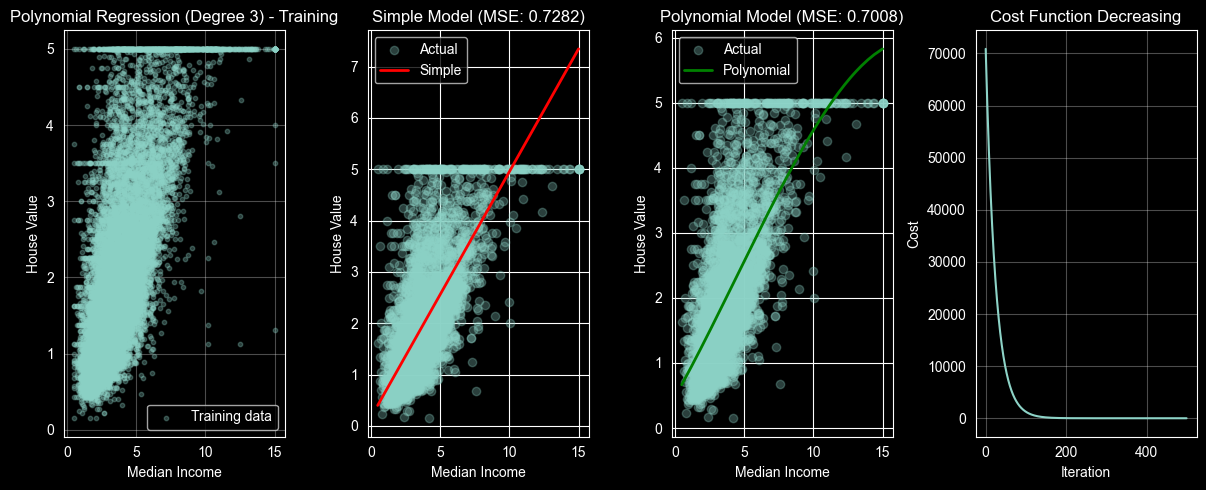

In [16]:
# Plot
plt.figure(figsize=(12, 5))

# Plot 1: The Train Plot
plt.subplot(1, 4, 1)
plt.scatter(X_train_simple, y_train, alpha=0.3, s=10, label='Training data')
plt.xlabel("Median Income")
plt.ylabel("House Value")
plt.title("Polynomial Regression (Degree 3) - Training")
plt.legend()
plt.grid(True, alpha=0.3)


# Plot 2: Simple Model
plt.subplot(1, 4, 2)
plt.scatter(X_test_simple, y_test, alpha=0.3, label='Actual')
# Sort for smooth line
sort_idx = np.argsort(X_test_simple.values.flatten())
X_sorted = X_test_simple.values[sort_idx]
y_pred_simple_sorted = y_pred_simple[sort_idx]
plt.plot(X_sorted, y_pred_simple_sorted, 'r-', linewidth=2, label='Simple')
plt.xlabel("Median Income")
plt.ylabel("House Value")
plt.title(f"Simple Model (MSE: {simple_mse:.4f})")
plt.legend()

# Plot 3: Polynomial Model
plt.subplot(1, 4, 3)
plt.scatter(X_test_simple, y_test, alpha=0.3, label='Actual')
# Sort for smooth line
sort_idx = np.argsort(X_test_simple.values.flatten())
X_sorted = X_test_simple.values[sort_idx]
y_pred_poly_sorted = y_pred_poly[sort_idx]
plt.plot(X_sorted, y_pred_poly_sorted, 'g-', linewidth=2, label='Polynomial')
plt.xlabel("Median Income")
plt.ylabel("House Value")
plt.title(f"Polynomial Model (MSE: {poly_mse:.4f})")
plt.legend()

# Plot 4: Cost history
plt.subplot(1, 4, 4)
plt.plot(model_poly.cost_history)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Cost Function Decreasing")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
def r_squared(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

simple_r2 = r_squared(y_test, y_pred_simple.flatten())
poly_r2 = r_squared(y_test, y_pred_poly.flatten())

print(f"Simple Model R²: {simple_r2:.4f}")
print(f"Polynomial Model R²: {poly_r2:.4f}")

Simple Model R²: 0.4443
Polynomial Model R²: 0.4652


## Interpretation:

- R² = 0.5 means model explains 50% of price variation

- Higher R² = better fit